# 04 — Redes Convolucionales 1D (Conv1D)
Input `(N, V_in, 23)`. Conv1D extrae patrones locales en la dimensión temporal.
Catálogo activo: **conv_s** (Conv1D + GlobalAvgPool). Descomentar `[EXTENDER]` para más variantes.

> Nota: Conv1D requiere V_in ≥ kernel_size (3). Para V_in=5 funciona correctamente.

https://github.com/Romequinco/TAREA_REDES_NEURONALES

In [46]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, yfinance as yf
import tensorflow as tf

warnings.simplefilter('ignore')

from keras import Sequential, Input
from keras.layers import Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS,
                   create_time_series_data, make_splits, eval_mae,
                   get_callbacks, restore_best_weights, compile_model,
                   plot_mae_matrix, build_results_df, best_per_window)

In [47]:
# ── HIPERPARÁMETROS ───────────────────────────────────────────
EPOCHS     = 900
BATCH_SIZE = 64
QUICK_MODE = False
if QUICK_MODE: EPOCHS = 50

precios = yf.download(TICKERS, start='1960-01-01', auto_adjust=True, progress=False)['Close']
precios.dropna(axis=1, inplace=True)
returns = np.log(precios).diff().dropna()
print(f'Retornos: {returns.shape}  |  EPOCHS={EPOCHS}')

Retornos: (16200, 23)  |  EPOCHS=900


### Fijación de la semilla 

<div style="text-align: justify;">
Fijar la semilla sirve para hacer el entrenamiento del modelo más reproducible entre ejecuciones: controla la aleatoriedad de la inicialización de pesos, del orden en que Keras presenta los datos durante fit y de otras operaciones estocásticas de TensorFlow, de modo que, usando los mismos datos y la misma configuración, obtengas resultados mucho más parecidos o incluso iguales; en tu notebook no afecta realmente a la separación train/val/test, porque esa partición ya está fijada por orden temporal con shuffle=False.
</div>

In [ ]:
# Waiting 

## Tamaños de Ventanas 

Existen **16 posibles combinaciones** de tamaños de ventanas de entrada-salida. Estas combinaciones se obtienen al cruzar las ventanas de entrada (`V_in`) con las ventanas de salida (`V_out`).

Las combinaciones consideradas son:

| Nº | `V_in` días | `V_out` días |
|---:|------------:|-------------:|
| 1  | 5  | 1  |
| 2  | 5  | 5  |
| 3  | 5  | 30 |
| 4  | 5  | 90 |
| 5  | 10 | 1  |
| 6  | 10 | 5  |
| 7  | 10 | 30 |
| 8  | 10 | 90 |
| 9  | 30 | 1  |
| 10 | 30 | 5  |
| 11 | 30 | 30 |
| 12 | 30 | 90 |
| 13 | 90 | 1  |
| 14 | 90 | 5  |
| 15 | 90 | 30 |
| 16 | 90 | 90 |

Se entrenará **un modelo para cada combinación de ventanas**, con el objetivo de comparar su rendimiento y determinar cuál de ellas ofrece la mejor opción.

# Implementación de los modelos

In [49]:
# Configuración del modelo

V_INS = [5, 10, 30, 90]
V_OUTS = [1, 5, 30, 90]

L2_REG = 0
LEARNING_RATE = 0.3 

def build_conv_s_model(v_in, l2_reg=L2_REG, learning_rate=LEARNING_RATE):
    models = Sequential([
        Input((v_in, 23)),
        Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(l2_reg)),
        GlobalAveragePooling1D(),
        Dense(23)
    ])

    models.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mae',
        metrics=['mae']
    )
    
    return models

In [50]:
for V_in in V_INS:
    print(f'\n{"─"*50}\nconv_s  (V_in={V_in})\n{"─"*50}')
    build_conv_s_model(V_in).summary()



──────────────────────────────────────────────────
conv_s  (V_in=5)
──────────────────────────────────────────────────


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 3, 64)          │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,975 (23.34 KB)

 Trainable params: 5,975 (23.34 KB)

...

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 88, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_11     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,975 (23.34 KB)

 Trainable params: 5,975 (23.34 KB)

 Non-trainable params: 0 (0.00 B)

[01/16] Entrenando model_1 | in= 5 out= 1
conv_s | in= 5 out= 1 | train=0.0120 val=0.0121 test=0.0299 ep=900


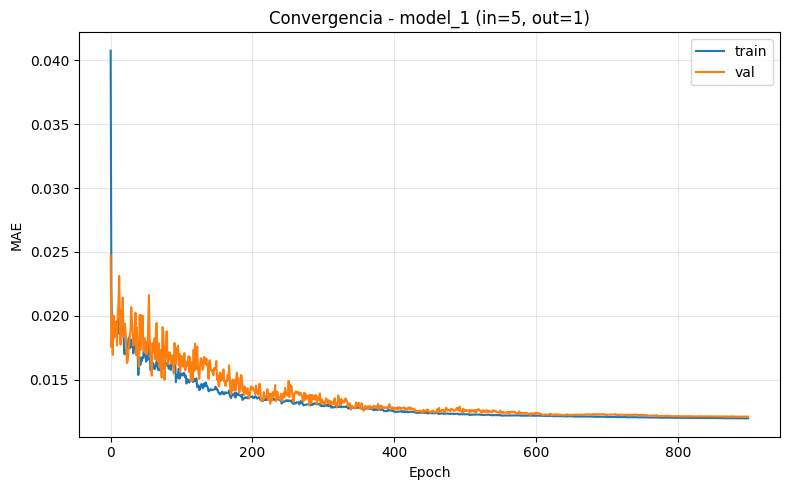

[02/16] Entrenando model_2 | in= 5 out= 5
conv_s | in= 5 out= 5 | train=0.0056 val=0.0074 test=0.0296 ep=900


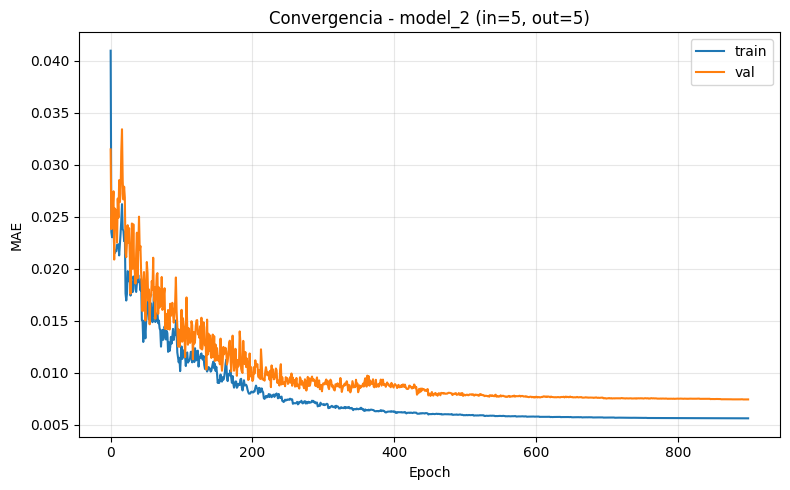

[03/16] Entrenando model_3 | in= 5 out=30
conv_s | in= 5 out=30 | train=0.0023 val=0.0055 test=0.0172 ep=900


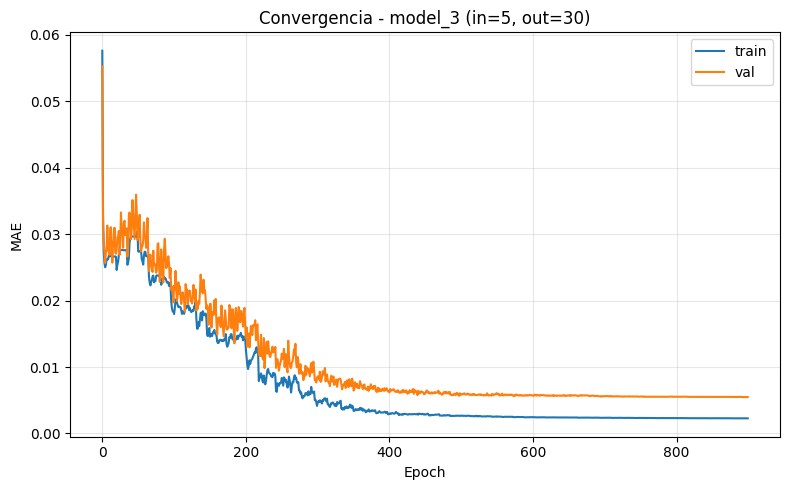

[04/16] Entrenando model_4 | in= 5 out=90
conv_s | in= 5 out=90 | train=0.0013 val=0.0025 test=0.0098 ep=900


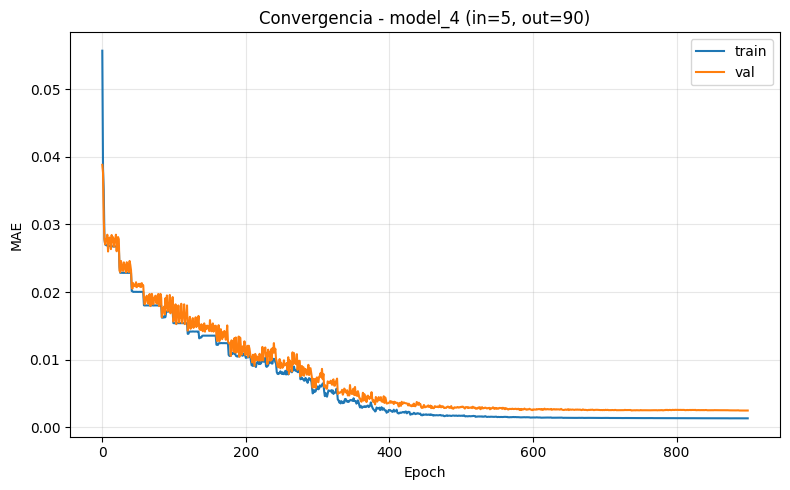

[05/16] Entrenando model_5 | in=10 out= 1
conv_s | in=10 out= 1 | train=0.0120 val=0.0123 test=0.0180 ep=900


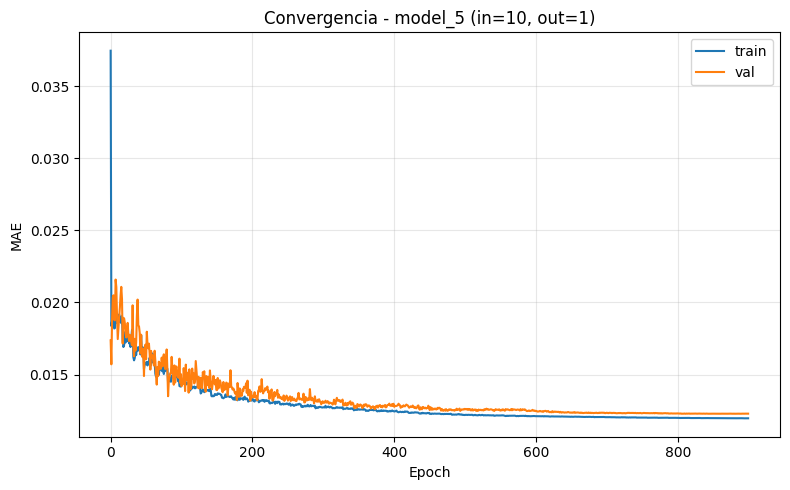

[06/16] Entrenando model_6 | in=10 out= 5
conv_s | in=10 out= 5 | train=0.0056 val=0.0057 test=0.0175 ep=900


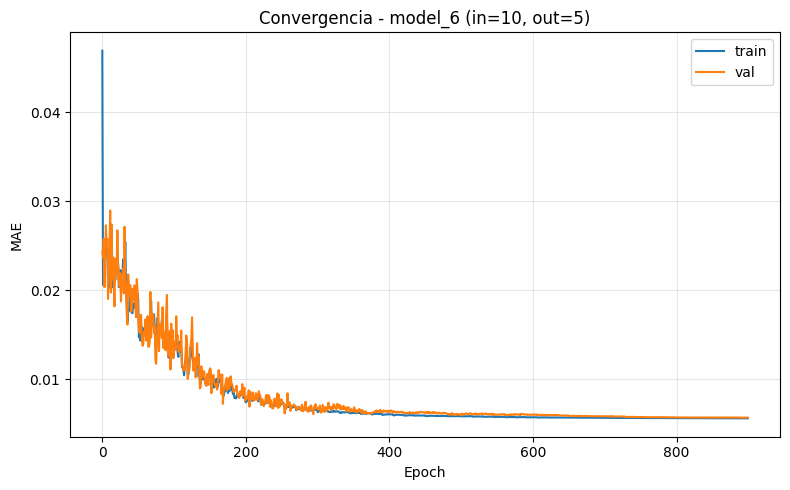

[07/16] Entrenando model_7 | in=10 out=30
conv_s | in=10 out=30 | train=0.0023 val=0.0038 test=0.0070 ep=900


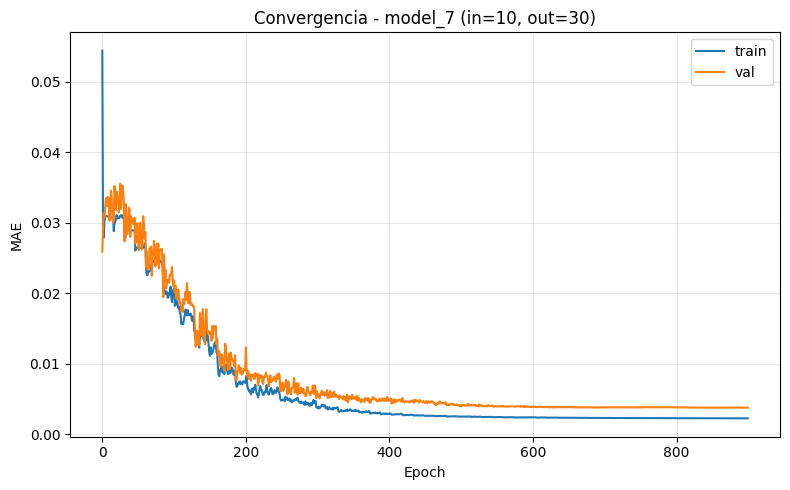

[08/16] Entrenando model_8 | in=10 out=90
conv_s | in=10 out=90 | train=0.0013 val=0.0051 test=0.0134 ep=900


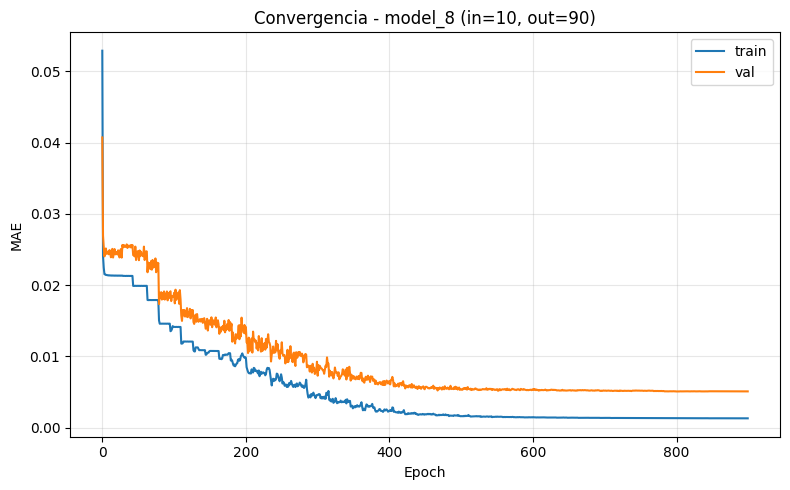

[09/16] Entrenando model_9 | in=30 out= 1
conv_s | in=30 out= 1 | train=0.0120 val=0.0138 test=0.0243 ep=900


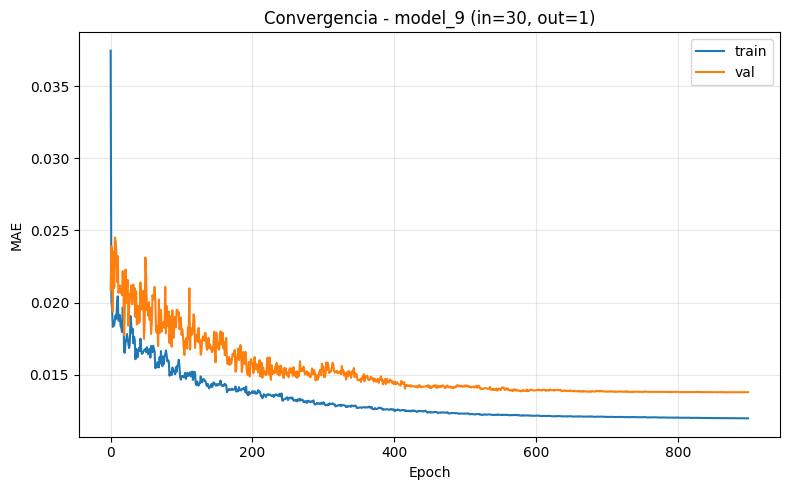

[10/16] Entrenando model_10 | in=30 out= 5
conv_s | in=30 out= 5 | train=0.0056 val=0.0060 test=0.0112 ep=900


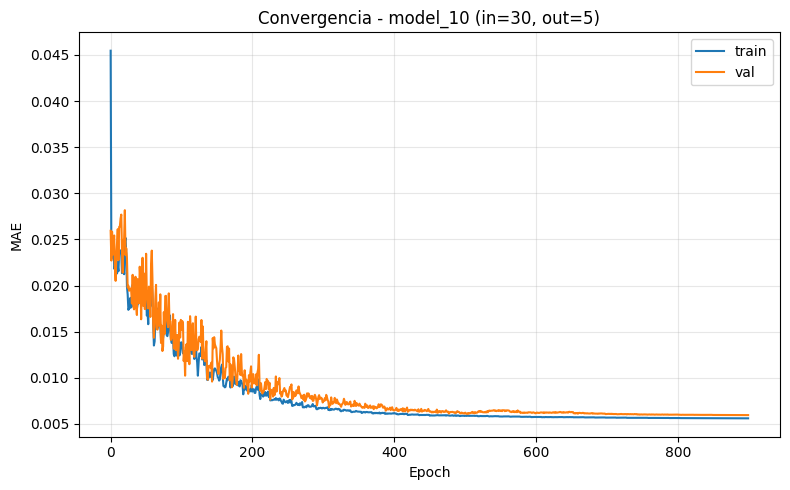

[11/16] Entrenando model_11 | in=30 out=30
conv_s | in=30 out=30 | train=0.0023 val=0.0032 test=0.0057 ep=900


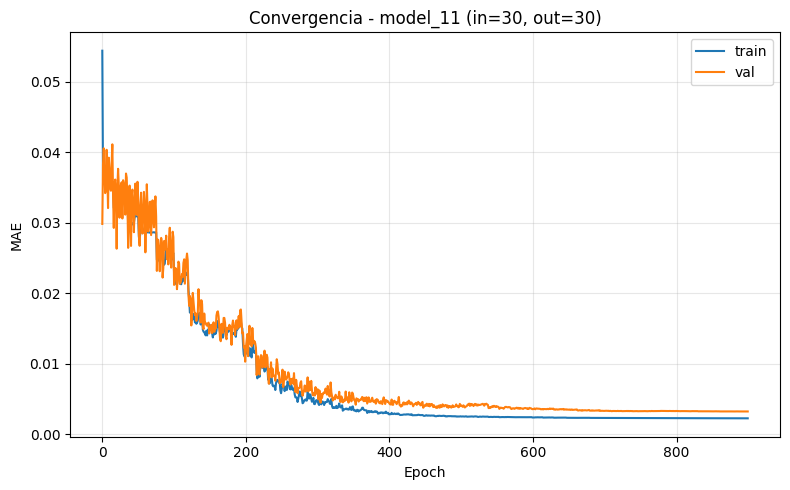

[12/16] Entrenando model_12 | in=30 out=90
conv_s | in=30 out=90 | train=0.0013 val=0.0026 test=0.0092 ep=900


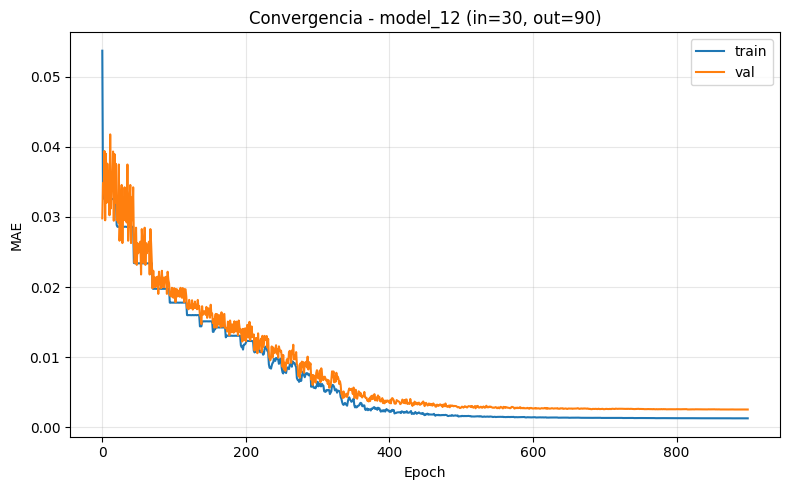

[13/16] Entrenando model_13 | in=90 out= 1
conv_s | in=90 out= 1 | train=0.0120 val=0.0107 test=0.0161 ep=900


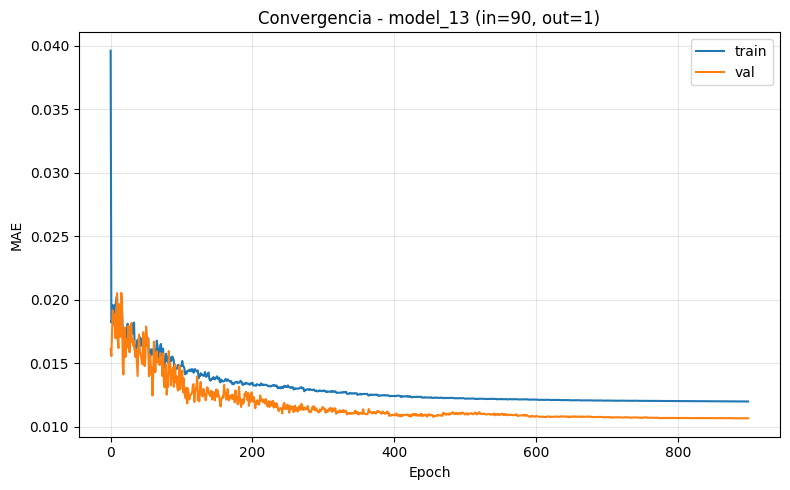

[14/16] Entrenando model_14 | in=90 out= 5
conv_s | in=90 out= 5 | train=0.0056 val=0.0076 test=0.0160 ep=900


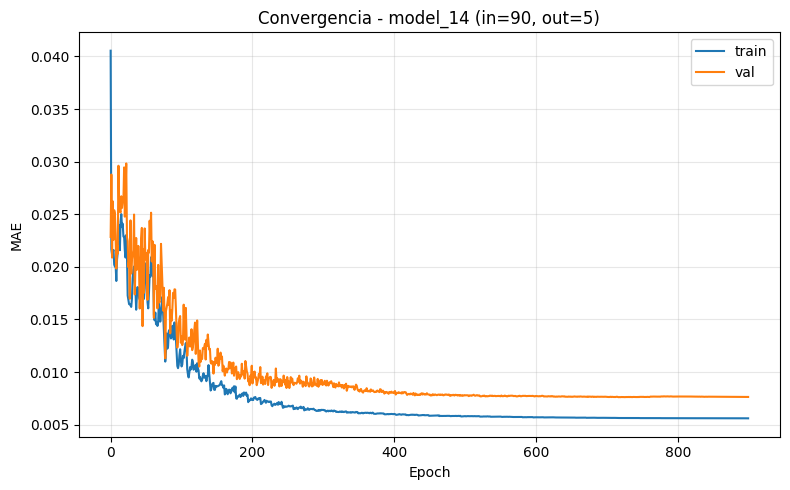

[15/16] Entrenando model_15 | in=90 out=30
conv_s | in=90 out=30 | train=0.0023 val=0.0025 test=0.0087 ep=900


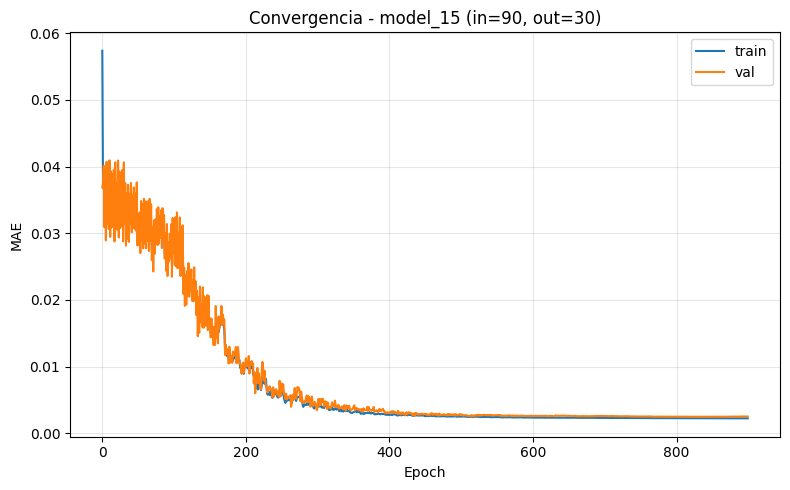

[16/16] Entrenando model_16 | in=90 out=90
conv_s | in=90 out=90 | train=0.0013 val=0.0031 test=0.0108 ep=900


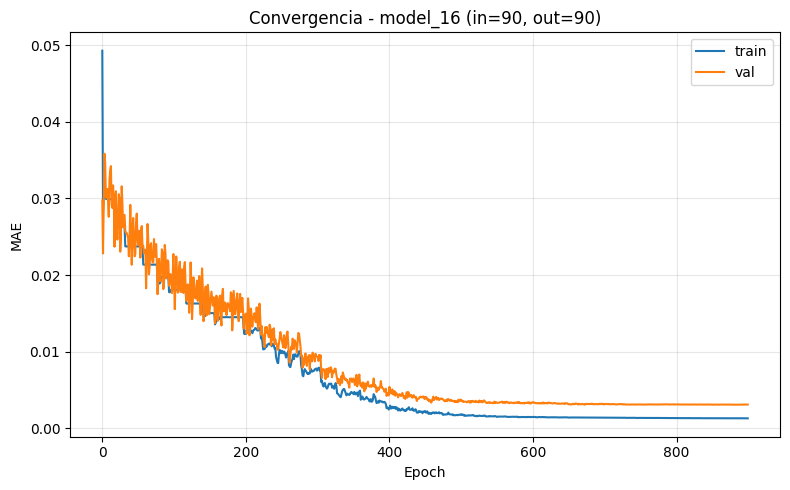

Entrenamiento total terminado.


In [52]:
# CELDA 2: entrenamiento

tf.keras.backend.clear_session()

combos = [(v_in, v_out) for v_in in V_INS for v_out in V_OUTS]

conv_models = {}
conv_histories = {}
conv_results = []
conv_split_mats = {
    split: pd.DataFrame(index=V_INS, columns=V_OUTS, dtype=float)
    for split in ['train', 'val', 'test']
}

for idx, (V_in, V_out) in enumerate(combos, start=1):
    print(f'[{idx:02d}/{len(combos)}] Entrenando model_{idx} | in={V_in:2d} out={V_out:2d}')

    X, y = create_time_series_data(returns, V_in, V_out)
    X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

    model = build_conv_s_model(V_in)

    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(),
        verbose=0
    )

    restore_best_weights(model)

    result = {
        'train': eval_mae(model, X_tr, y_tr),
        'val':   eval_mae(model, X_v, y_v),
        'test':  eval_mae(model, X_ts, y_ts),
        'params': model.count_params(),
        'ep': len(hist.history['loss'])
    }

    conv_models[(V_in, V_out)] = model
    conv_histories[(V_in, V_out)] = hist

    globals()[f'model_{idx}'] = model
    globals()[f'hist_{idx}'] = hist
    globals()[f'result_{idx}'] = result

    for split in ['train', 'val', 'test']:
        conv_split_mats[split].loc[V_in, V_out] = result[split]

    conv_results.append({
        'modelo': idx,
        'V_in': V_in,
        'V_out': V_out,
        'train': result['train'],
        'val': result['val'],
        'test': result['test'],
        'params': result['params'],
        'ep': result['ep']
    })

    print(
        f'conv_s | in={V_in:2d} out={V_out:2d} | '
        f'train={result["train"]:.4f} '
        f'val={result["val"]:.4f} '
        f'test={result["test"]:.4f} '
        f'ep={result["ep"]}'
    )

    plt.figure(figsize=(8, 5))
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='val')
    plt.title(f'Convergencia - model_{idx} (in={V_in}, out={V_out})')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print('Entrenamiento total terminado.')


In [ ]:
# CELDA 3: resumen global + matrices de color

if 'conv_results' not in globals() or 'conv_split_mats' not in globals():
    raise ValueError('Ejecuta antes la celda de entrenamiento.')

df_conv_resumen = pd.DataFrame(conv_results).sort_values('modelo').reset_index(drop=True)
display(df_conv_resumen.round(4))

for split in ['train', 'val', 'test']:
    print(f'Conv1D - MAE {split}')
    display(conv_split_mats[split].round(4))
    plot_mae_matrix(conv_split_mats[split], title=f'Conv1D - MAE {split}')
